# **Initial Base of the Code**

The initial base of the code is done by Gibran which acts as the foundation of our final project.

# Import Image

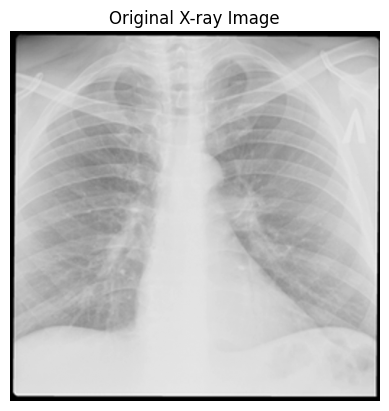

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Tuberculosis-10.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title('Original X-ray Image')
plt.axis('off')
plt.show()


In [ ]:
def preprocess_image(image):
    """
    Applies CLAHE and Median Filtering to a grayscale image.
    """
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_image = clahe.apply(image)

    filtered_image = cv2.medianBlur(clahe_image, 5)

    return filtered_image

# Pre-Processing

In [ ]:
def preprocess_image(image):
    """
    Preprocessing for grayscale chest X-ray images.
    Steps:
    1. Normalize intensity values
    2. Apply CLAHE for contrast enhancement
    3. Apply median and Gaussian filtering for denoising
    4. (Optional) Apply Laplacian sharpening
    Returns all processed images for visualization or further use.
    """

    normalized = cv2.normalize(image, None, alpha=0, beta=1,
                               norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply((normalized * 255).astype(np.uint8))

    median_filtered = cv2.medianBlur(enhanced, 3)
    gaussian_filtered = cv2.GaussianBlur(enhanced, (5, 5), 0)

    laplacian = cv2.Laplacian(gaussian_filtered, cv2.CV_64F)
    sharpened = cv2.convertScaleAbs(gaussian_filtered - 0.5 * laplacian)

    return {
        "normalized": normalized,
        "enhanced": enhanced,
        "median_filtered": median_filtered,
        "gaussian_filtered": gaussian_filtered,
        "sharpened": sharpened
    }


Display Pre-Processing

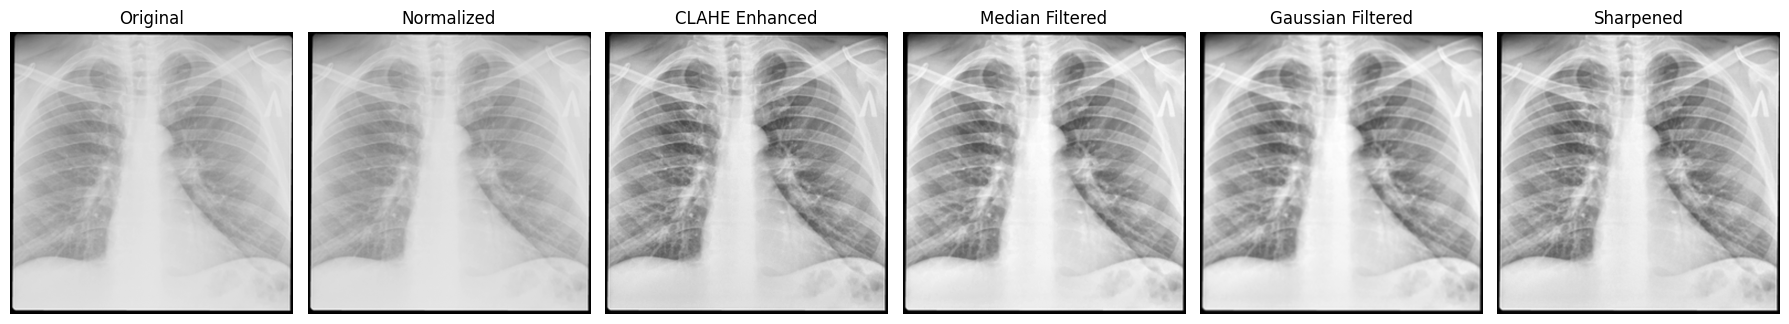

In [ ]:
results = preprocess_image(img)

filtered_image = results['median_filtered']


import matplotlib.pyplot as plt

titles = ['Original', 'Normalized', 'CLAHE Enhanced', 'Median Filtered', 'Gaussian Filtered', 'Sharpened']
images = [
    img,
    results['normalized'],
    results['enhanced'],
    results['median_filtered'],
    results['gaussian_filtered'],
    results['sharpened']
]

plt.figure(figsize=(18, 6))
for i in range(len(images)):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


# Lung Segmentation Code (Otsu + Morphology)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segment_lungs_v2(image):
    """
    Improved lung segmentation using Otsu thresholding and refined morphology,
    NOW WITH LUNG SEPARATION.
    """

    blur = cv2.GaussianBlur(image, (5, 5), 0)

    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    thresh = cv2.bitwise_not(thresh)

    kernel_open = np.ones((3, 3), np.uint8)
    kernel_close = np.ones((7, 7), np.uint8)
    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_open, iterations=2)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close, iterations=2)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed, connectivity=8)

    if stats.shape[0] < 2:
        print("Warning: No lung components found.")
        mask = np.zeros_like(image, dtype=np.uint8)
        return {
            "blurred": blur,
            "thresholded": thresh,
            "morph_opened": opened,
            "morph_closed": closed,
            "mask": mask,
            "segmented": np.zeros_like(image, dtype=np.uint8)
        }

    sizes = stats[1:, cv2.CC_STAT_AREA]
    min_size = np.max(sizes) * 0.2

    initial_mask = np.zeros_like(labels, dtype=np.uint8)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_size:
            initial_mask[labels == i] = 255

    mask = initial_mask.copy()
    h, w = mask.shape
    center_x = w // 2
    width_pixels = 10

    start_col = max(0, center_x - (width_pixels // 2))
    end_col = min(w, center_x + (width_pixels // 2) + 1)

    mask[:, start_col:end_col] = 0


    segmented = cv2.bitwise_and(image, image, mask=mask)

    return {
        "blurred": blur,
        "thresholded": thresh,
        "morph_opened": opened,
        "morph_closed": initial_mask,
        "mask": mask,
        "segmented": segmented
    }

Display Segmenation Results

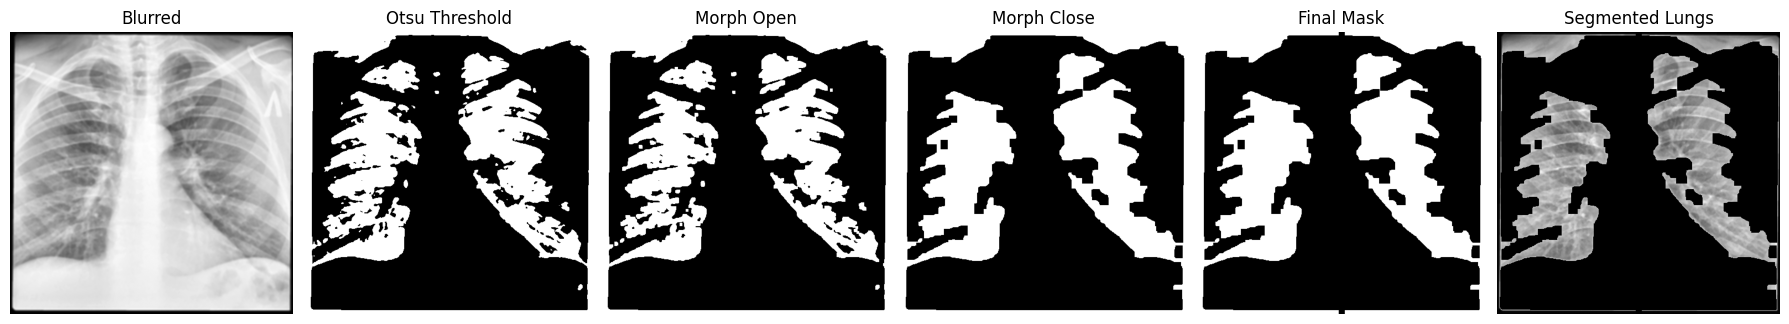

In [ ]:
seg_v2 = segment_lungs_v2(filtered_image)

titles = ['Blurred', 'Otsu Threshold', 'Morph Open', 'Morph Close', 'Final Mask', 'Segmented Lungs']
images = [
    seg_v2['blurred'],
    seg_v2['thresholded'],
    seg_v2['morph_opened'],
    seg_v2['morph_closed'],
    seg_v2['mask'],
    seg_v2['segmented']
]

plt.figure(figsize=(18, 6))
for i in range(len(images)):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


# Lung Feature Extraction

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.measure import shannon_entropy

def extract_lung_features(image, mask):
    """
    Extract geometric and intensity-based features from segmented lungs.
    Parameters:
        image: original grayscale image
        mask: binary lung mask
    Returns:
        annotated image and feature data for each lung
    """

    labeled_mask = label(mask)

    annotated = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    features = []

    for region in regionprops(labeled_mask, intensity_image=image):
        if region.area < 5000:
            continue

        area = region.area
        perimeter = region.perimeter
        centroid = region.centroid
        bbox = region.bbox

        mean_intensity = region.mean_intensity
        std_intensity = np.std(image[labeled_mask == region.label])
        entropy = shannon_entropy(image[labeled_mask == region.label])

        features.append({
            "label": region.label,
            "area": area,
            "perimeter": perimeter,
            "centroid": centroid,
            "mean_intensity": mean_intensity,
            "std_intensity": std_intensity,
            "entropy": entropy
        })

        (minr, minc, maxr, maxc) = bbox
        cv2.rectangle(annotated, (minc, minr), (maxc, maxr), (0, 255, 0), 2)
        cv2.circle(annotated, (int(centroid[1]), int(centroid[0])), 4, (0, 0, 255), -1)
        cv2.putText(annotated, f"Lung {region.label}", (minc, minr - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

    return annotated, features


Display Lung Extraction

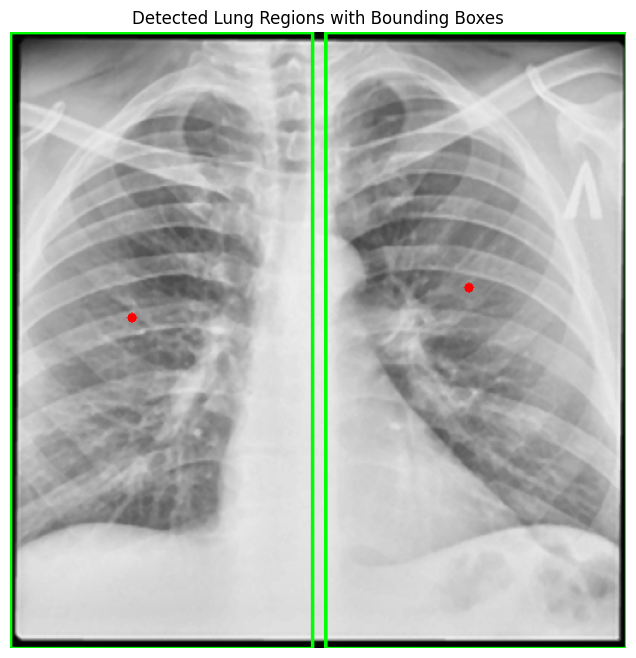

,label,area,perimeter,centroid,mean_intensity,std_intensity,entropy
0,1,45034.0,3758.727056,"(237.24408224896746, 101.85946174001866)",120.305702,48.627678,6.584402
1,2,44967.0,3861.846897,"(212.97982965285655, 381.8879622834523)",123.778704,43.915501,6.576764


In [ ]:
mask = seg_v2['mask']
segmented = seg_v2['segmented']

annotated_img, lung_features = extract_lung_features(filtered_image, mask)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Lung Regions with Bounding Boxes")
plt.axis("off")
plt.show()

import pandas as pd
pd.DataFrame(lung_features)


# **Training the Model**

**Add New Imports for ML**

In [ ]:
import pandas as pd
import glob
import os

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

**Define the Feature Helper Function**

In [ ]:
def process_image_features(feature_list):
    """
    Converts the 2-row feature list into a 1-row dictionary
    by identifying left and right lungs based on their x-coordinate.
    """
    # We must have two lungs to proceed
    if not feature_list or len(feature_list) != 2:
        print("Warning: Did not find exactly two lungs in an image. Skipping.")
        return None

    # Identify left vs. right lung based on the 'x' coordinate (centroid[1])
    if feature_list[0]['centroid'][1] < feature_list[1]['centroid'][1]:
        left_lung = feature_list[0]
        right_lung = feature_list[1]
    else:
        left_lung = feature_list[1]
        right_lung = feature_list[0]

    # Create a single row of features
    row = {
        'left_area': left_lung['area'],
        'left_perimeter': left_lung['perimeter'],
        'left_mean_intensity': left_lung['mean_intensity'],
        'left_std_intensity': left_lung['std_intensity'],
        'left_entropy': left_lung['entropy'],

        'right_area': right_lung['area'],
        'right_perimeter': right_lung['perimeter'],
        'right_mean_intensity': right_lung['mean_intensity'],
        'right_std_intensity': right_lung['std_intensity'],
        'right_entropy': right_lung['entropy'],

        # "Difference" features are often very powerful for ML
        'area_diff': left_lung['area'] - right_lung['area'],
        'entropy_diff': left_lung['entropy'] - right_lung['entropy'],
        'intensity_diff': left_lung['mean_intensity'] - right_lung['mean_intensity']
    }
    return row

**Download Your Data (The Kaggle API part)**

In [ ]:
from google.colab import files

print("Please upload your kaggle.json file:")
files.upload()

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gibranbasyir","key":"8269b19eb60086dbd479c69607bb05c4"}'}

In [ ]:
!pip install kaggle --quiet
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the CORRECT dataset
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset

# Make a folder to hold your data
!mkdir -p /content/data

# Unzip the file into that folder (using the CORRECT filename)
!unzip tuberculosis-tb-chest-xray-dataset.zip -d /content/data

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
tuberculosis-tb-chest-xray-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  tuberculosis-tb-chest-xray-dataset.zip
  inflating: /content/data/TB_Chest_Radiography_Database/Normal.metadata.xlsx  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-10.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-100.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1000.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1001.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1002.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1003.png  
  inflating: /content/data/TB_Chest_Radiography_Database

**The Main Loop (This processes all images)**

In [ ]:
all_features_list = []
all_labels_list = []

NORMAL_PATH = "/content/data/TB_Chest_Radiography_Database/Normal/*.png"
TB_PATH = "/content/data/TB_Chest_Radiography_Database/Tuberculosis/*.png"

# Process NORMAL images (Label = 0)
print(f"Processing Normal images from: {NORMAL_PATH}")
for img_path in glob.glob(NORMAL_PATH):
    original_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if original_image is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue

    image_to_process = original_image

    # Run your segmentation (on the pre-processed image)
    seg_v2 = segment_lungs_v2(image_to_process)

    # Run your feature extraction (use the processed image and new mask)
    annotated_img, features = extract_lung_features(image_to_process, seg_v2['mask'])

    # Process the 2-row features into a 1-row entry
    row = process_image_features(features)

    if row:
        all_features_list.append(row)
        all_labels_list.append(0) # 0 for Normal

# Process TB images (Label = 1)
print(f"Processing Tuberculosis images from: {TB_PATH}")
for img_path in glob.glob(TB_PATH):
    original_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if original_image is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue

    image_to_process = original_image # (Replace this with your pre-processed image)

    seg_v2 = segment_lungs_v2(image_to_process)
    annotated_img, features = extract_lung_features(image_to_process, seg_v2['mask'])

    row = process_image_features(features)

    if row:
        all_features_list.append(row)
        all_labels_list.append(1) # 1 for Tuberculosis

df = pd.DataFrame(all_features_list)
df['label'] = all_labels_list

print("\n--- Dataset Creation Complete ---")
print(f"Total samples processed: {len(df)}")
if len(df) > 0:
    print("Dataset head:")
    print(df.head())
else:
    print("Warning: No data was loaded. Check your file paths (NORMAL_PATH, TB_PATH).")

Processing Normal images from: /content/data/TB_Chest_Radiography_Database/Normal/*.png
Processing Tuberculosis images from: /content/data/TB_Chest_Radiography_Database/Tuberculosis/*.png

--- Dataset Creation Complete ---
Total samples processed: 2700
Dataset head:
   left_area  left_perimeter  left_mean_intensity  left_std_intensity  \
0    36484.0     1130.340187           100.333297           36.629852   
1    70724.0     1912.565584           104.217720           28.228097   
2    68983.0     1871.712770            66.596219           43.971955   
3    50116.0     1760.239682            90.653464           46.481808   
4    81281.0     2577.619408            52.830403           34.080432   

   left_entropy  right_area  right_perimeter  right_mean_intensity  \
0      6.876392     36238.0      1432.156421             97.460483   
1      6.675143     61762.0      1637.009235             89.642839   
2      6.469349     60066.0      1419.144228             66.032897   
3      6.50568

Define X (Features) and y (Target)

In [ ]:
# X gets all columns EXCEPT 'label'
X = df.drop('label', axis=1)

# y gets ONLY the 'label' column
y = df['label']

print("--- Features (X) ---")
print(X.head())
print("\n--- Target (y) ---")
print(y.head())

--- Features (X) ---
   left_area  left_perimeter  left_mean_intensity  left_std_intensity  \
0    36484.0     1130.340187           100.333297           36.629852   
1    70724.0     1912.565584           104.217720           28.228097   
2    68983.0     1871.712770            66.596219           43.971955   
3    50116.0     1760.239682            90.653464           46.481808   
4    81281.0     2577.619408            52.830403           34.080432   

   left_entropy  right_area  right_perimeter  right_mean_intensity  \
0      6.876392     36238.0      1432.156421             97.460483   
1      6.675143     61762.0      1637.009235             89.642839   
2      6.469349     60066.0      1419.144228             66.032897   
3      6.505681     34884.0      1201.227489            106.851623   
4      6.565692     51969.0      2172.572727             57.786084   

   right_std_intensity  right_entropy  area_diff  entropy_diff  intensity_diff  
0            39.827107       7.091814 

Split Data into Training and Testing Sets

In [ ]:
# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Total samples: 2700
Training samples: 2160
Testing samples: 540


Train the Random Forest Model

In [ ]:
# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
print("Training the Random Forest model...")
model.fit(X_train, y_train)
print("Model training complete!")

Training the Random Forest model...
Model training complete!


Test and Evaluate the Model (Final Result)

In [ ]:
# Make predictions on the unseen test data
y_pred = model.predict(X_test)

# Check the overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print("--- Model Evaluation ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# Print a detailed classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Tuberculosis (1)']))

# Print the confusion matrix
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

--- Model Evaluation ---
Overall Accuracy: 92.59%

--- Classification Report ---
                  precision    recall  f1-score   support

      Normal (0)       0.93      0.98      0.96       438
Tuberculosis (1)       0.88      0.71      0.78       102

        accuracy                           0.93       540
       macro avg       0.91      0.84      0.87       540
    weighted avg       0.92      0.93      0.92       540


--- Confusion Matrix ---
[[428  10]
 [ 30  72]]


**Save Trained Model**

In [ ]:
import joblib

# Save the model to a file
joblib.dump(model, 'tb_classifier_model.pkl')

print("Model saved to tb_classifier_model.pkl")

Model saved to tb_classifier_model.pkl


**Create Your "Prediction" Cell**

In [ ]:
import joblib
import cv2
import pandas as pd
import numpy as np
import os.path

model_path = 'tb_classifier_model.pkl'
if os.path.exists(model_path):
    loaded_model = joblib.load(model_path)
    print("Model loaded successfully!")
else:
    print("Error: Model file 'tb_classifier_model.pkl' not found.")
    print("Please make sure you have run the 'joblib.dump' cell first.")

test_image_name = "Tuberculosis-42.png"
print(f"Attempting to process: {test_image_name}")


if not os.path.exists(test_image_name):
    print(f"\nError: File not found: '{test_image_name}'")
    print("Please make sure you have uploaded the file to the Files sidebar.")
else:
    new_image = cv2.imread(test_image_name, cv2.IMREAD_GRAYSCALE)

    print(f"\nProcessing {test_image_name}...")

    preprocessed_img = preprocess_image(new_image)
    seg_v2 = segment_lungs_v2(preprocessed_img)
    annotated_img, features = extract_lung_features(preprocessed_img, seg_v2['mask'])

    single_row_features = process_image_features(features)

    if single_row_features:
        feature_df = pd.DataFrame([single_row_features])

        prediction = loaded_model.predict(feature_df)
        prediction_proba = loaded_model.predict_proba(feature_df)

        print("\n--- PREDICTION RESULT ---")
        if prediction[0] == 0:
            print("Diagnosis: NORMAL")
            print(f"Confidence: {prediction_proba[0][0]*100:.2f}%")
        else:
            print("Diagnosis: TUBERCULOSIS DETECTED")
            print(f"Confidence: {prediction_proba[0][1]*100:.2f}%")
    else:
        print("\nCould not process the image: Did not find two separate lungs.")

Model loaded successfully!
Attempting to process: Normal-19.png

Processing Normal-19.png...

--- PREDICTION RESULT ---
Diagnosis: NORMAL
Confidence: 85.00%
